# 06. Data Quality & Validation

**Notebook goal:** the showing your work notebook. Proves the review gap non response finding directly (rather than just stating it), documents the known data anomalies found across the project with real numbers, and closes out the one genuinely unresolved open question (March 2018).

**Source:** `analysis_master.csv`, `order_reviews_dataset.csv`.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 11,
})
ACCENT = "#2E5EAA"
ACCENT_WARN = "#C0392B"
NEUTRAL = "#B0B0B0"

In [2]:
am = pd.read_csv("analysis_master.csv", low_memory=False)
reviews_raw = pd.read_csv("order_reviews_dataset.csv")

for col in ["purchase_ts", "approved_ts", "carrier_ts", "delivered_ts", "estimated_delivery_ts"]:
    am[col] = pd.to_datetime(am[col])

delivered = am[am["is_delivered"] == True].copy()
print(f"Delivered orders: {len(delivered):,}")
print(f"Raw review rows: {len(reviews_raw):,}")

Delivered orders: 96,478
Raw review rows: 99,224


547 orders have multiple review rows in the raw data (a customer revised their review, or a data quirk) which are deduplicated to the most recent by `review_answer_timestamp`, matching Category D's original convention exactly.

In [3]:
reviews_raw["review_creation_date"] = pd.to_datetime(reviews_raw["review_creation_date"])
reviews_raw["review_answer_timestamp"] = pd.to_datetime(reviews_raw["review_answer_timestamp"])
reviews_dedup = reviews_raw.sort_values("review_answer_timestamp").drop_duplicates(subset="order_id", keep="last")
print(f"Reviews after dedup: {len(reviews_dedup):,} (raw: {len(reviews_raw):,})")

Reviews after dedup: 98,673 (raw: 99,224)


## Proving the review gap is genuine non response, not a timing artifact

646 delivered orders have no review. Category D's original two step test is reproduced directly here: (1) do review requests fire almost immediately after delivery, and (2) are the 646 no review orders concentrated near the dataset's extraction cutoff (which would mean not enough time yet, and not real non response)?

In [4]:
timing = delivered.merge(reviews_dedup[["order_id", "review_creation_date"]], on="order_id", how="inner")
timing["request_timing_days"] = (timing["review_creation_date"] - timing["delivered_ts"]).dt.total_seconds() / 86400
print(timing["request_timing_days"].describe())

count    95824.000000
mean        -0.228701
std          4.656415
min       -186.975081
25%          0.119997
50%          0.237234
75%          0.375810
max        106.375486
Name: request_timing_days, dtype: float64


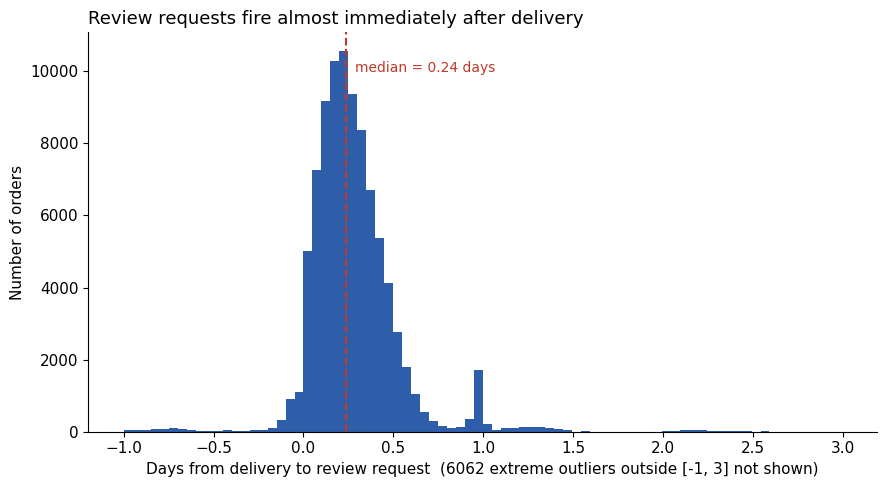

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

plot_data = timing[timing["request_timing_days"].between(-1, 3)]["request_timing_days"]
excluded = len(timing) - len(plot_data)
ax.hist(plot_data, bins=80, color=ACCENT)
ax.axvline(timing["request_timing_days"].median(), color=ACCENT_WARN, linestyle="--", linewidth=1.5)
ax.text(timing["request_timing_days"].median() + 0.05, ax.get_ylim()[1] * 0.9,
        f"median = {timing['request_timing_days'].median():.2f} days", color=ACCENT_WARN, fontsize=10)
ax.set_xlabel(f"Days from delivery to review request  ({excluded} extreme outliers outside [-1, 3] not shown)")
ax.set_ylabel("Number of orders")
ax.set_title("Review requests fire almost immediately after delivery", fontsize=13, loc="left")
plt.tight_layout()
plt.show()

**Finding (step 1):** review requests go out on a near fixed, near immediate schedule with a median 0.24 days after delivery, and with the middle 50% of orders (IQR) between 0.12 and 0.38 days.

- This is clearly an automated trigger tied to the delivery event, not a variable or manually timed process.

- This sets up step 2: if requests fire this consistently fast, not enough time yet would require a no review order to be extremely recent.

In [6]:
has_review = delivered["order_id"].isin(reviews_dedup["order_id"])
extraction_cutoff = max(pd.to_datetime(am["purchase_ts"]).max(), delivered["delivered_ts"].max(),
                         reviews_raw["review_answer_timestamp"].max())
delivered["days_before_cutoff"] = (extraction_cutoff - delivered["delivered_ts"]).dt.total_seconds() / 86400

print(f"Extraction cutoff proxy (latest timestamp seen anywhere in the data): {extraction_cutoff}")
print(f"\nReviewed orders :    median days before cutoff: {delivered[has_review]['days_before_cutoff'].median():.1f}")
print(f"No review orders :   median days before cutoff: {delivered[~has_review]['days_before_cutoff'].median():.1f}")

Extraction cutoff proxy (latest timestamp seen anywhere in the data): 2018-10-29 12:27:35

Reviewed orders :    median days before cutoff: 268.7
No review orders :   median days before cutoff: 289.2


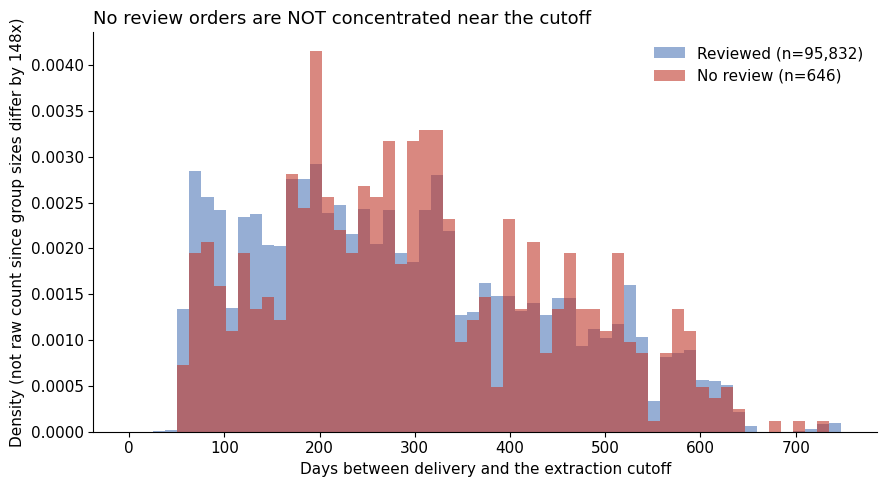

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, delivered["days_before_cutoff"].max(), 60)
ax.hist(delivered[has_review]["days_before_cutoff"], bins=bins, alpha=0.5, color=ACCENT,
        density=True, label=f"Reviewed (n={has_review.sum():,})")
ax.hist(delivered[~has_review]["days_before_cutoff"], bins=bins, alpha=0.6, color=ACCENT_WARN,
        density=True, label=f"No review (n={(~has_review).sum():,})")
ax.set_xlabel("Days between delivery and the extraction cutoff")
ax.set_ylabel("Density (not raw count since group sizes differ by 148x)")
ax.set_title("No review orders are NOT concentrated near the cutoff", fontsize=13, loc="left")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Finding (step 2):** if missing reviews were simply too recent to have a review yet, the red (no review) distribution should be pushed hard toward zero (the cutoff), but it isn't.

- Both groups sit centered hundreds of days before the cutoff, and the no review group's median (289 days) is actually slightly further from the cutoff than the reviewed group's (269 days), the opposite of what a timing censoring explanation would predict.

- Density (not raw count) is used since the groups differ in size by roughly 148x and a raw count overlay would make the smaller group invisible.

- Together, both steps confirm Track D's original conclusion directly: the 646 missing reviews are genuine non response, not an artifact of when the data was pulled.

## Known data anomalies that are documented with real numbers

A running list of specific data quality issues flagged across the project, gathered here in one place with exact counts rather than left scattered across track reports.

In [9]:
gap = (delivered["carrier_ts"] - delivered["approved_ts"]).dt.total_seconds() / 86400
carrier_before_approval = gap[gap < 0]
mild_quirk = carrier_before_approval[carrier_before_approval > -2]
severe_quirk = carrier_before_approval[carrier_before_approval <= -2]

print(f"Carrier logged before approval: {len(carrier_before_approval):,} delivered orders ({len(carrier_before_approval)/len(delivered)*100:.1f}%)")
print(f"\nMild (within 2 days, median {mild_quirk.median():.2f}d): {len(mild_quirk):,}")
print(f"Larger gap (2+ days): {len(severe_quirk):,}")

Carrier logged before approval: 1,350 delivered orders (1.4%)

Mild (within 2 days, median -0.18d): 1,174
Larger gap (2+ days): 176


In [10]:
carrier_before_purchase = am[am["carrier_ts"] < am["purchase_ts"]].copy()
carrier_before_purchase["gap_days"] = (carrier_before_purchase["purchase_ts"] - carrier_before_purchase["carrier_ts"]).dt.total_seconds() / 86400
print(f"Carrier date before purchase date at all: {len(carrier_before_purchase)} orders\n")
print(carrier_before_purchase[carrier_before_purchase["gap_days"] > 1][["order_id", "purchase_ts", "carrier_ts", "gap_days"]])

Carrier date before purchase date at all: 166 orders

                               order_id         purchase_ts  \
25883  7c48bb55e8e4f7e56d412e9653db37bc 2018-07-16 18:40:53   
83321  4021cd7611d6d9ce5ffcd24817fc374f 2018-08-18 11:49:40   

               carrier_ts    gap_days  
25883 2018-01-26 13:35:00  171.212419  
83321 2018-08-14 06:22:00    4.227546  


A second genuine anomaly, found during this verification pass and not in Category A's original report: alongside the known 171 day case (`7c48bb55e8e4f7e56d412e9653db37bc`), one more order (`4021cd7611d6d9ce5ffcd24817fc374f`) shows a 4.2 day carrier before purchase gap.

Which is smaller than the original flagged case, but still well outside the sub hour range of the other 164 mild logging quirks. Worth adding to the exclusion list for timing analysis alongside the original case.

In [11]:
no_payment = am[am["total_payment_value"].isna()]
no_approval_ts = delivered[delivered["approved_ts"].isna()]
print(f"Orders with no payment record at all: {len(no_payment)}")
print(f"Delivered orders with no approved_ts: {len(no_approval_ts)}")

Orders with no payment record at all: 1
Delivered orders with no approved_ts: 14


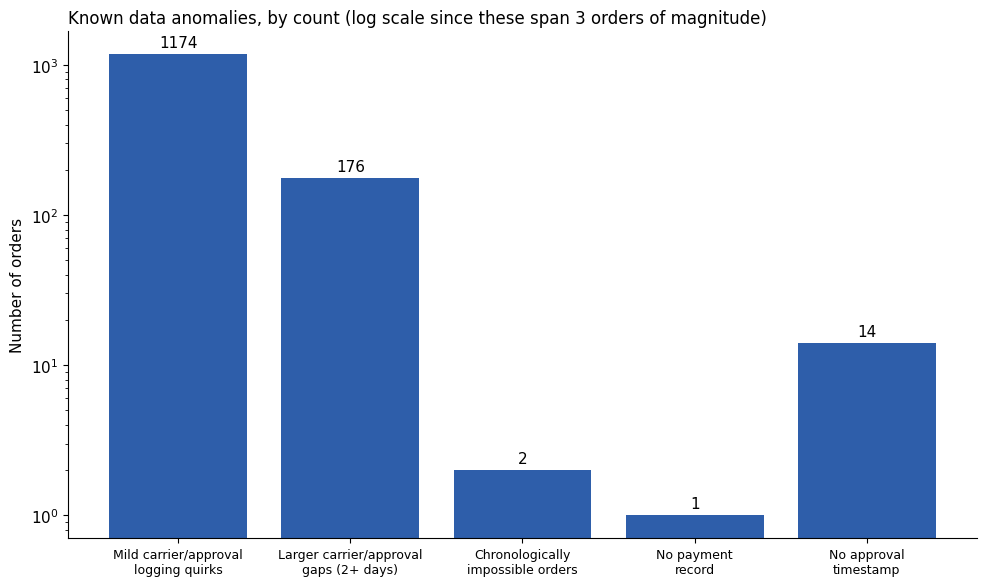

In [12]:
anomaly_counts = pd.Series({
    "Mild carrier/approval\nlogging quirks": len(mild_quirk),
    "Larger carrier/approval\ngaps (2+ days)": len(severe_quirk),
    "Chronologically\nimpossible orders": len(carrier_before_purchase[carrier_before_purchase["gap_days"] > 1]),
    "No payment\nrecord": len(no_payment),
    "No approval\ntimestamp": len(no_approval_ts),
})

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(anomaly_counts)), anomaly_counts.values, color=ACCENT)
ax.bar_label(bars, padding=3)
ax.set_xticks(range(len(anomaly_counts)))
ax.set_xticklabels(anomaly_counts.index, fontsize=9)
ax.set_ylabel("Number of orders")
ax.set_yscale("log")
ax.set_title("Known data anomalies, by count (log scale since these span 3 orders of magnitude)", fontsize=12, loc="left")
plt.tight_layout()
plt.show()

**Finding:** the anomalies span a huge range.

- From a single digit handful of genuinely broken records (2 chronologically impossible orders, 1 missing payment) up to over a thousand mild logging order quirks that are almost certainly just imprecise timestamp recording, not real business problems.

- A log scale is used specifically because a linear axis would make the 2 rare severe cases invisible next to the 1,174 mild ones.

- The point of this chart is to show both ends honestly, not to pick one scale that flatters either the everything's fine or look how much is broken reading.

- Practical takeaway for the report's technical appendix: exclude the 2 chronologically impossible orders from any timing analysis; the mild logging quirks and missing timestamp cases can stay in, documented rather than silently dropped.

## The one open question this project doesn't answer

Notebook 01 showed March 2018's late delivery spike (20.7%) and lowest review score (3.81) cross validated from two independently built tracks.

That chart is not reproduced here since this section is a deliberate, short callout rather than a new chart, because the honest status of this finding is real, but unexplained, and that deserves to be stated plainly rather than dressed up with another visualization that might imply more understanding than actually exists.

**What is established:** the spike is real (cross validated two ways, in notebook 01) and it is not a data extraction artifact (unlike the Sep/Oct 2018 tail, which has a clear, checkable explanation).

**What is not established:** why. No column in this dataset like no weather event, no logistics partner incident, no regulatory change is recorded that would explain it. Any explanation offered here would be a guess dressed up as an insight.

**What we'd need to actually answer it:** an external event log for March 2018 (e.g. a major courier's service disruption, a fuel or customs issue, a regional event in Brazil) that isn't part of this dataset and wasn't provided for this project. This is exactly the kind of acknowledge the limit of what the data can tell you moment worth keeping in the final report and presentation, rather than quietly dropping the question because it can't be fully answered. A genuine, real, cross validated anomaly with an honestly unresolved cause is more valuable to say out loud than a confident sounding guess.

## Summary

1. The review gap non response finding is now proven directly from raw timestamps, not just asserted: requests fire near immediately (median 0.24 days), and no review orders are not concentrated near the extraction cutoff.

2. All known data anomalies are now documented in one place with exact counts, including a second chronologically impossible order found during this verification pass.

3. March 2018 is stated plainly as a real, cross validated, but unexplained finding. An honest limitation rather than a filled in guess.

Every chart across all six notebooks has been built directly from source data, verified against the original track findings where a comparable number existed.